#This notebook has to be run on Google Colab T4

##Preparing
The authors' GitHub has been cloned on our own GitHub and updated, and the ModelNet40 dataset is available through the Kaggle API.

In [ ]:
cd /content

/content


In [ ]:
!GIT_LFS_SKIP_SMUDGE=1 git clone https://github.com/Athirhama/Dl.git


Cloning into 'Dl'...
remote: Enumerating objects: 81, done.
remote: Counting objects: 100% (81/81), done.
remote: Compressing objects: 100% (43/43), done.
remote: Total 81 (delta 31), reused 77 (delta 27), pack-reused 0 (from 0)
Receiving objects: 100% (81/81), 24.99 KiB | 2.78 MiB/s, done.
Resolving deltas: 100% (31/31), done.


In [ ]:
cd /content/Dl/

/content/Dl


In [ ]:
!git lfs pull

In [ ]:
mkdir data

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("chenxaoyu/modelnet-normal-resampled")

print("Path to dataset files:", path)

100%|██████████| 1.65G/1.65G [00:21<00:00, 81.7MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/chenxaoyu/modelnet-normal-resampled/versions/1


In [ ]:
!mv /root/.cache/kagglehub/datasets/chenxaoyu/modelnet-normal-resampled/versions/1 \
   /content/Dl/data/

In [ ]:
!mv /content/Dl/data/1/modelnet40_normal_resampled /content/Dl/data/

In [ ]:
!rm -rf /content/Dl/data/1/

##Training
 Do not execute unless you want to see if it works, we provided the ckeckpoint on GitHub.

In [ ]:
#!python train_cls_conv.py --model pointconv_modelnet40 --normal --epoch 10 --batchsize 64

The size of train data is 9843
The size of test data is 2468
No existing model, starting training from scratch...
Epoch 1 (1/10):
100% 154/154 [02:46<00:00,  1.08s/it]
Train Accuracy: 0.199277
 Loss: 3.581222
 Test Accuracy: 0.247974   ***  Best Accuracy: 0.000000
Epoch 2 (2/10):
100% 154/154 [02:44<00:00,  1.07s/it]
Train Accuracy: 0.368873
 Loss: 1.985498
 Test Accuracy: 0.412075   ***  Best Accuracy: 0.000000
Epoch 3 (3/10):
100% 154/154 [02:45<00:00,  1.07s/it]
Train Accuracy: 0.537684
 Loss: 1.307921
 Test Accuracy: 0.657618   ***  Best Accuracy: 0.000000
Epoch 4 (4/10):
100% 154/154 [02:50<00:00,  1.10s/it]
Train Accuracy: 0.640311
 Loss: 1.309267
 Test Accuracy: 0.718395   ***  Best Accuracy: 0.000000
Epoch 5 (5/10):
100% 154/154 [02:47<00:00,  1.09s/it]
Train Accuracy: 0.688733
 Loss: 1.135476
 Test Accuracy: 0.786062   ***  Best Accuracy: 0.000000
Epoch 6 (6/10):
100% 154/154 [02:54<00:00,  1.13s/it]
Train Accuracy: 0.728840
 Loss: 0.759222
 Test Accuracy: 0.809562   ***  Best

##Testing

In [ ]:
!python eval_cls_conv.py --checkpoint ./checkpoints/checkpoint.pth --normal --batchsize 64

The size of test data is 2468
Load CheckPoint...
Start evaluating...
100% 39/39 [00:34<00:00,  1.13it/s]
Total Accuracy: 0.850071


##Robustness analysis

In [ ]:
import os
import sys
from pathlib import Path
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from google.colab import files
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from data_utils.ModelNetDataLoader import ModelNetDataLoader
from model.pointconv import PointConvDensityClsSsg as PointConvClsSsg

BATCH_SIZE = 64
NUM_POINTS = 1024 #each point cloud is composed of 1024 3D points
NUM_WORKERS = 2
USE_NORMALS = True #each 3D point has a feature normal

DATA_PATH = Path("data/modelnet40_normal_resampled")
CHECKPOINT_PATH = Path("checkpoints/checkpoint.pth")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

assert CHECKPOINT_PATH.exists(), \
    f"Checkpoint not found at {CHECKPOINT_PATH}"

Using device: cuda


In [ ]:
#load dataset
print('Loading dataset...')
test_dataset = ModelNetDataLoader(root=str(DATA_PATH), npoint=NUM_POINTS, split='test', normal_channel=USE_NORMALS)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
print(f"Test data size: {len(test_dataset)}")

#load model
num_class = 40
classifier = PointConvClsSsg(num_class).to(device)

if os.path.exists(CHECKPOINT_PATH):
    print(f'Loading CheckPoint from {CHECKPOINT_PATH}...')
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)
    classifier.load_state_dict(checkpoint['model_state_dict'])
    print("Model loaded successfully.")
else:
    print(f"WARNING: Checkpoint file not found at {CHECKPOINT_PATH}")

Loading dataset...
The size of test data is 2468
Test data size: 2468
Loading CheckPoint from checkpoints/checkpoint.pth...
Model loaded successfully.


###Attack I: Point Dropping (decimation)

In [ ]:
def drop_points_attack(points, num_to_keep): #keep num_to_keep points among the points defining the point cloud

    B, C, N = points.shape #B is the batch size, C the number of input channels and N the number of points in a point cloud
    if num_to_keep >= N:
        return points
    device = points.device

    perm = torch.randperm(N, device=device)
    points_shuffled = points[:, :, perm]
    points_kept = points_shuffled[:, :, :num_to_keep] #keep the first num_to_keep points among the randomly permuted points defining the point cloud

    return points_kept

Test on 1024 points:   0%|          | 0/39 [00:00<?, ?it/s]

Number of points kept : 1024 | Accuracy : 0.8537


Test on 768 points:   0%|          | 0/39 [00:00<?, ?it/s]

Number of points kept :  768 | Accuracy : 0.8509


Test on 512 points:   0%|          | 0/39 [00:00<?, ?it/s]

Number of points kept :  512 | Accuracy : 0.8318


Test on 256 points:   0%|          | 0/39 [00:00<?, ?it/s]

Number of points kept :  256 | Accuracy : 0.4259


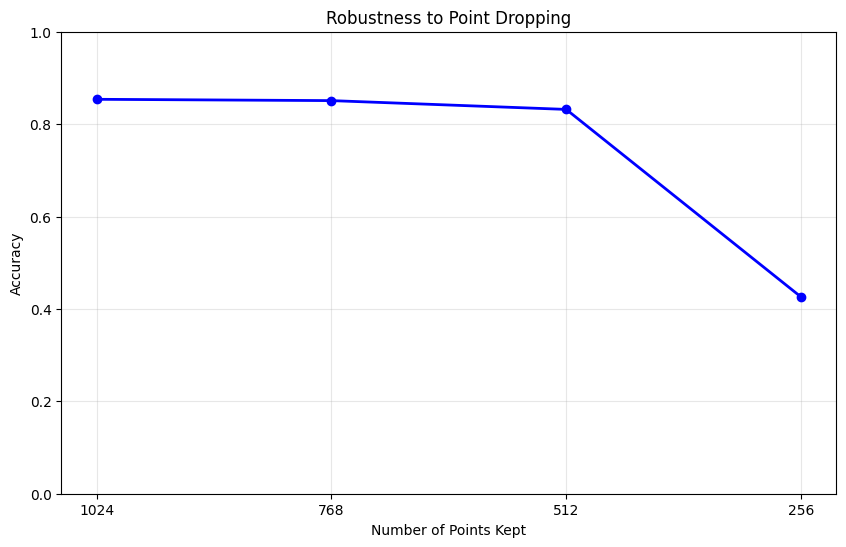

In [ ]:
keep_levels = [1024, 768, 512, 256] #number of points to keep

classifier.eval()

accuracies_drop = []

for k in keep_levels:
    total_correct = 0
    total_samples = 0

    for data in tqdm(test_loader, desc=f"Test on {k} points", leave=False):
        pointcloud, target = data
        points = pointcloud.permute(0, 2, 1).to(device)
        target = target[:, 0].to(device)

        points_dropped = drop_points_attack(points, k) #the attack

        with torch.no_grad():
              pred_logits = classifier(points_dropped[:, :3, :], points_dropped[:, 3:, :])
              pred_choice = pred_logits.argmax(dim=1)

        correct = pred_choice.eq(target).sum().item() #number of correct predictions
        total_correct += correct
        total_samples += points.size(0)

    acc = total_correct / total_samples
    accuracies_drop.append(acc)
    print(f"Number of points kept : {k:4d} | Accuracy : {acc:.4f}")

#plot
plt.figure(figsize=(10, 6))
plt.plot(keep_levels, accuracies_drop, 'o-', linewidth=2, color='blue')
plt.title(f'Robustness to Point Dropping')
plt.xlabel('Number of Points Kept')
plt.ylabel('Accuracy')
plt.grid(True, alpha=0.3)
plt.xticks(keep_levels)
plt.ylim(0, 1.0)
plt.gca().invert_xaxis()
plt.show()

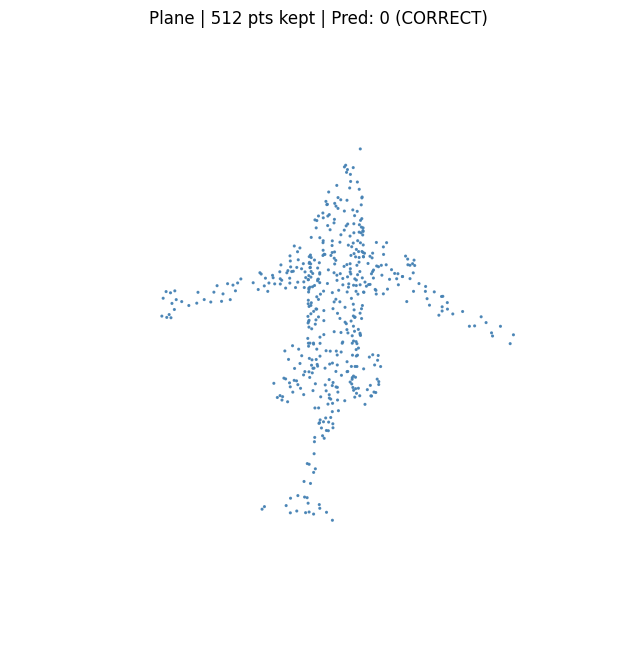

In [ ]:
TARGET_CLASS_INDEX = 0 #plane class
K_POINTS = 512 #number of points to keep

def plot_drop_points(points_np, pred_class, true_class, k):
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection='3d')

    ax.scatter(points_np[:, 0],
               points_np[:, 1],
               points_np[:, 2],
               s=6, c='steelblue', marker='.', alpha=0.9)

    ax.axis('off')
    ax.view_init(elev=150, azim=100)

    status = "CORRECT" if pred_class == true_class else "WRONG"
    ax.set_title(f"Plane | {k} pts kept | Pred: {pred_class} ({status})")

    plt.show()

#we are looking for a plane which is initially well classified, and still well classified after the attack is performed (cf. mask)
classifier.eval()
found = False

for pointcloud, target in test_loader:
    points = pointcloud.permute(0, 2, 1).to(device)
    target = target[:, 0].to(device)

    with torch.no_grad():
        pred_clean = classifier(points[:, :3, :],
                                points[:, 3:, :]).argmax(1)

    points_dropped = drop_points_attack(points, K_POINTS)

    with torch.no_grad():
        pred_drop = classifier(points_dropped[:, :3, :],
                               points_dropped[:, 3:, :]).argmax(1)

    mask = (target == TARGET_CLASS_INDEX) & \
           (pred_clean == target) & \
           (pred_drop == target)

    if mask.any():
        idx = torch.where(mask)[0][0].item()
        found = True
        break

#plot
if found:
    final_points_np = points_dropped[idx, :3, :].detach().cpu().numpy().T

    plot_drop_points(
        points_np=final_points_np,
        pred_class=pred_drop[idx].item(),
        true_class=target[idx].item(),
        k=K_POINTS
    )
else:
    print("No correctly classified plane found after point dropping")

###Attack II: White Noise (Jitter)

In [ ]:
def apply_gaussian_noise(points, sigma): #add white noise with sd = sigma to the coordinates of the points defining the points cloud
    if sigma <= 0:
        return points

    noise = torch.randn_like(points[:, :3, :]) * sigma #noise added to each coordinate
    points_noisy = points.clone()
    points_noisy[:, :3, :] += noise

    return points_noisy

Testing Sigma 0:   0%|          | 0/39 [00:00<?, ?it/s]

Sigma: 0.000 | Accuracy: 0.8537


Testing Sigma 0.005:   0%|          | 0/39 [00:00<?, ?it/s]

Sigma: 0.005 | Accuracy: 0.8562


Testing Sigma 0.01:   0%|          | 0/39 [00:00<?, ?it/s]

...

Sigma: 0.080 | Accuracy: 0.1499


Testing Sigma 0.1:   0%|          | 0/39 [00:00<?, ?it/s]

Sigma: 0.100 | Accuracy: 0.0754


Testing Sigma 0.15:   0%|          | 0/39 [00:00<?, ?it/s]

Sigma: 0.150 | Accuracy: 0.0405


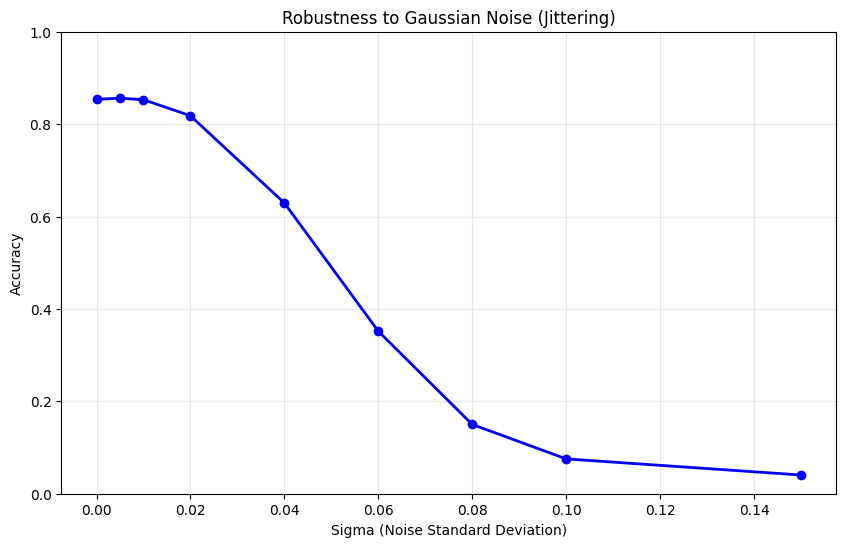

In [ ]:
sigma_levels = [0, 0.005, 0.01, 0.02, 0.04, 0.06, 0.08, 0.1, 0.15] #sigma values to be tested

classifier.eval()
accuracies_noise = []

for sigma in sigma_levels:
    total_correct = 0
    total_samples = 0

    with torch.no_grad():
        for data in tqdm(test_loader, desc=f"Testing Sigma {sigma}", leave=False):
            pointcloud, target = data
            target = target[:, 0].to(device)
            points = pointcloud.permute(0, 2, 1).to(device)

            points_noisy = apply_gaussian_noise(points, sigma) #the attack

            pred = classifier(points_noisy[:, :3, :], points_noisy[:, 3:, :])
            pred_choice = pred.max(1)[1]
            correct = pred_choice.eq(target).sum().item() #number of correct predictions
            total_correct += correct
            total_samples += points.size(0)

    acc = total_correct / total_samples
    accuracies_noise.append(acc)
    print(f"Sigma: {sigma:.3f} | Accuracy: {acc:.4f}")

#plot
plt.figure(figsize=(10, 6))
plt.plot(sigma_levels, accuracies_noise, 'o-', linewidth=2, color='blue')
plt.title('Robustness to Gaussian Noise (Jittering)')
plt.xlabel('Sigma (Noise Standard Deviation)')
plt.ylabel('Accuracy')
plt.grid(True, alpha=0.3)
plt.ylim(0, 1.0)
plt.show()

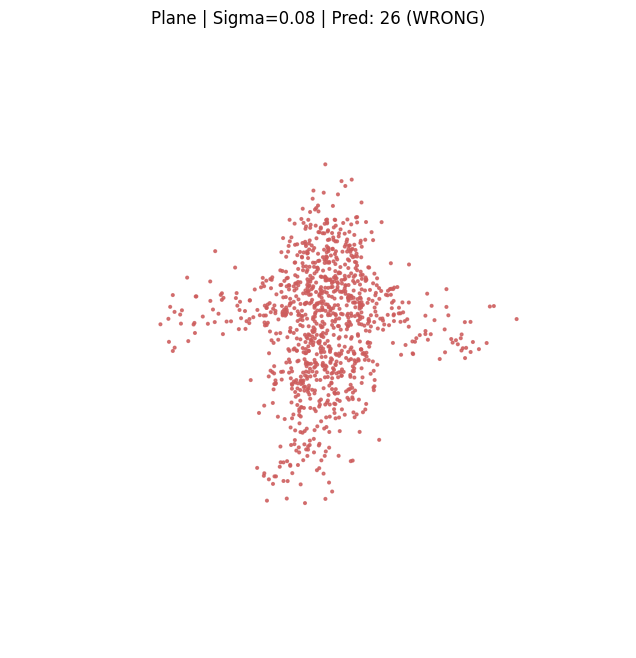

In [ ]:
TARGET_CLASS_INDEX = 0  #plane class
SIGMA = 0.08 #magnitude of the attack

def plot_gaussian(points_np, sigma, pred_class, true_class):
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection='3d')

    status = "WRONG" if pred_class != true_class else "CORRECT"
    color = "indianred" if status == "WRONG" else "steelblue"

    ax.scatter(points_np[:, 0], points_np[:, 1], points_np[:, 2],
               s=15, c=color, marker='.', alpha=0.8,
               label='plane')

    ax.axis('off')
    ax.view_init(elev=150, azim=100)

    ax.set_title(f"Plane | Sigma={sigma} | Pred: {pred_class} ({status})")

    plt.show()

#we are looking for a plane which is initially well classified, but then misclassified when the attack is performed (cf. mask)
classifier.eval()
found = False

for pointcloud, target in test_loader:

    points = pointcloud.permute(0, 2, 1).to(device)
    target = target[:, 0].to(device)

    with torch.no_grad():
        pred_clean = classifier(points[:, :3, :],
                                points[:, 3:, :]).argmax(1)

    points_noisy = apply_gaussian_noise(points, SIGMA)
    with torch.no_grad():
        pred_noisy = classifier(points_noisy[:, :3, :],
                                points_noisy[:, 3:, :]).argmax(1)

    mask = (target == TARGET_CLASS_INDEX) & \
           (pred_clean == target) & \
           (pred_noisy != target)

    if mask.any():
        idx = torch.where(mask)[0][0].item()
        found = True
        break

#plot
if found:
    final_points_np = points_noisy[idx].detach().cpu().numpy().T

    plot_gaussian(
        points_np=final_points_np,
        sigma=SIGMA,
        pred_class=pred_noisy[idx].item(),
        true_class=target[idx].item()
    )
else:
    print("No misclassified plane found for this sigma")


###Attack III: Point Insertion (Outliers)

In [ ]:
def add_outlier_attack(points, num_outliers): #add num_outliers random points in the cube with side length [-1, 1]
    if num_outliers <= 0:
        return points

    B, C, N = points.shape #B is the batch size, C the number of input channels and N the number of points in a point cloud
    device = points.device

    outliers_xyz = (torch.rand((B, 3, num_outliers), device=device) * 2) - 1 #generate random points in the cube with side length [-1, 1]

    if C > 3: #in the case each 3D point in the point cloud has a feature normal
        outliers_feat = torch.zeros((B, C - 3, num_outliers), device=device) #we give a 0 normal to each outlier
        outliers = torch.cat([outliers_xyz, outliers_feat], dim=1)
    else:
        outliers = outliers_xyz

    noisy_points = torch.cat([points, outliers], dim=2) #3D points defining the point cloud + outliers

    return noisy_points

Testing +0 outliers:   0%|          | 0/39 [00:00<?, ?it/s]

Outliers Added:   0 | Accuracy: 0.8537


Testing +10 outliers:   0%|          | 0/39 [00:00<?, ?it/s]

Outliers Added:  10 | Accuracy: 0.6309


Testing +30 outliers:   0%|          | 0/39 [00:00<?, ?it/s]

...

Outliers Added:  70 | Accuracy: 0.0656


Testing +100 outliers:   0%|          | 0/39 [00:00<?, ?it/s]

Outliers Added: 100 | Accuracy: 0.0417


Testing +150 outliers:   0%|          | 0/39 [00:00<?, ?it/s]

Outliers Added: 150 | Accuracy: 0.0405


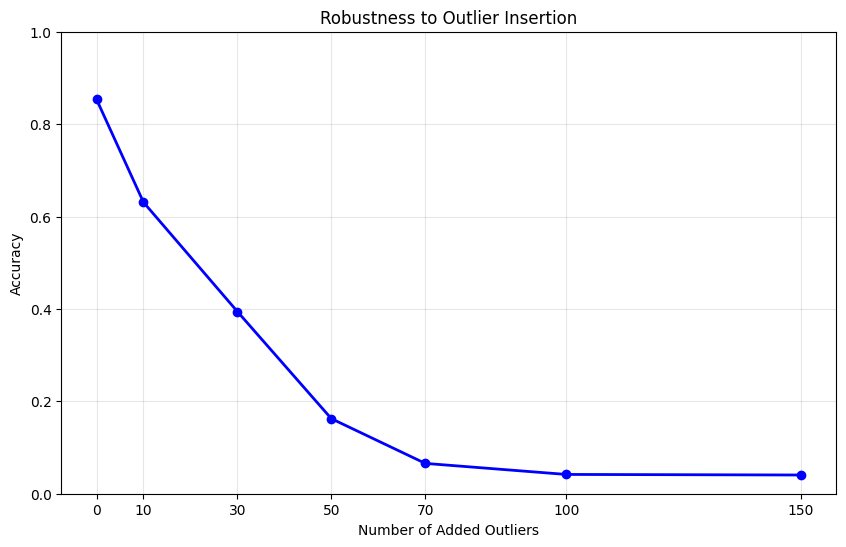

In [ ]:
outlier_levels = [0, 10, 30, 50, 70, 100, 150] #number of points to be added

classifier.eval()
accuracies = []

for n_out in outlier_levels:
    total_correct = 0
    total_samples = 0

    for data in tqdm(test_loader, desc=f"Testing +{n_out} outliers", leave=False):
        pointcloud, target = data
        target = target[:, 0]
        points = pointcloud.permute(0, 2, 1).to(device)
        target = target.to(device)

        points_attacked = add_outlier_attack(points, n_out) #the attack

        with torch.no_grad():
            pred = classifier(points_attacked[:, :3, :], points_attacked[:, 3:, :])

        pred_choice = pred.data.max(1)[1]
        correct = pred_choice.eq(target.long().data).sum() #number of correct predictions
        total_correct += correct.item()
        total_samples += points.size(0)

    acc = total_correct / total_samples
    accuracies.append(acc)
    print(f'Outliers Added: {n_out:3d} | Accuracy: {acc:.4f}')

#plot
plt.figure(figsize=(10, 6))
plt.plot(outlier_levels, accuracies, 'o-', linewidth=2, color='blue')
plt.title(f'Robustness to Outlier Insertion')
plt.xlabel('Number of Added Outliers')
plt.ylabel('Accuracy')
plt.grid(True, alpha=0.3)
plt.xticks(outlier_levels)
plt.ylim(0, 1.0)
plt.show()

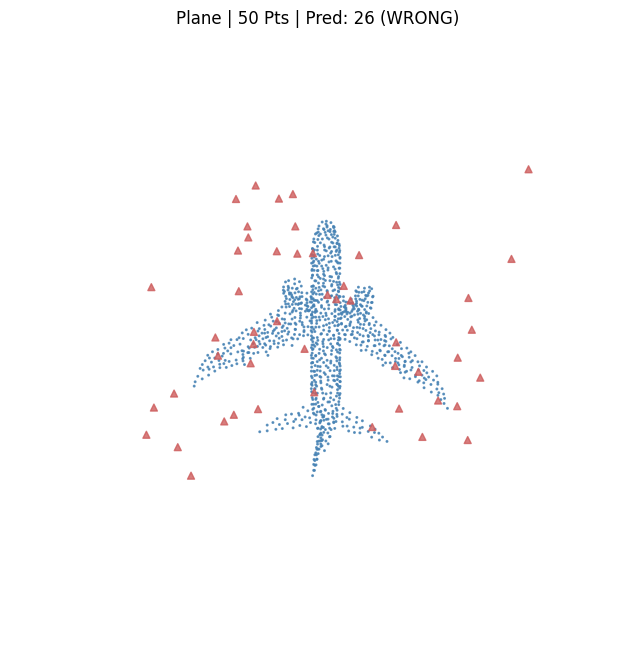

In [ ]:
TARGET_CLASS_INDEX = 0  #plane class
n_out = 50 #number of outliers to add

def plot_add_outlier(points_np, n_original, n_outliers, pred_class, true_class):
    clean_data = points_np[:n_original]
    noise_data = points_np[n_original:]

    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection='3d')

    ax.scatter(clean_data[:, 0], clean_data[:, 1], clean_data[:, 2],
               s=5, c='steelblue', marker='.', alpha=0.8, label='plane')

    if len(noise_data) > 0:
        ax.scatter(noise_data[:, 0], noise_data[:, 1], noise_data[:, 2],
                   s=25, c='indianred', marker='^', alpha=0.8, label='Noise')

    ax.axis('off')
    ax.view_init(elev=150, azim=100)

    status = "WRONG" if pred_class != true_class else "CORRECT"
    ax.set_title(f"Plane | {n_outliers} Pts | Pred: {pred_class} ({status})")

    plt.show()

#we are looking for a plane which is initially well classified, but then misclassified when the attack is performed (cf. mask)
classifier.eval()
found = False

for pointcloud, target in test_loader:
    points = pointcloud.permute(0, 2, 1).to(device)
    target = target[:, 0].to(device)

    with torch.no_grad():
        pred_clean = classifier(points[:, :3, :],
                                points[:, 3:, :]).argmax(1)

    points_weak = add_outlier_attack(points, n_out)
    with torch.no_grad():
        pred_weak = classifier(points_weak[:, :3, :],
                               points_weak[:, 3:, :]).argmax(1)

    mask = (target == TARGET_CLASS_INDEX) & \
           (pred_clean == target) & \
           (pred_weak != target)

    if mask.any():
        idx = torch.where(mask)[0][0].item()
        found = True
        break

#plot
if found:
    final_points_np = points_weak[idx].detach().cpu().numpy().T
    n_orig = points.shape[2]

    plot_add_outlier(
        points_np=final_points_np,
        n_original=n_orig,
        n_outliers=n_out,
        pred_class=pred_weak[idx].item(),
        true_class=target[idx].item()
    )
else:
    print("No misclassified plane found for this number of outliers")

###Attack IV: Fast Gradient Sign Method (FGSM)

In [ ]:
def fgsm_attack(data, epsilon, data_grad): #perform FGSM attack
    sign_data_grad = data_grad.sign()
    perturbed_data = data + epsilon * sign_data_grad
    return perturbed_data

Epsilon 0:   0%|          | 0/155 [00:00<?, ?it/s]

Epsilon : 0.000 | Accuracy : 0.8537


Epsilon 0.005:   0%|          | 0/155 [00:00<?, ?it/s]

Epsilon : 0.005 | Accuracy : 0.7686


Epsilon 0.01:   0%|          | 0/155 [00:00<?, ?it/s]

...

Epsilon : 0.050 | Accuracy : 0.2909


Epsilon 0.07:   0%|          | 0/155 [00:00<?, ?it/s]

Epsilon : 0.070 | Accuracy : 0.1856


Epsilon 0.1:   0%|          | 0/155 [00:00<?, ?it/s]

Epsilon : 0.100 | Accuracy : 0.1110


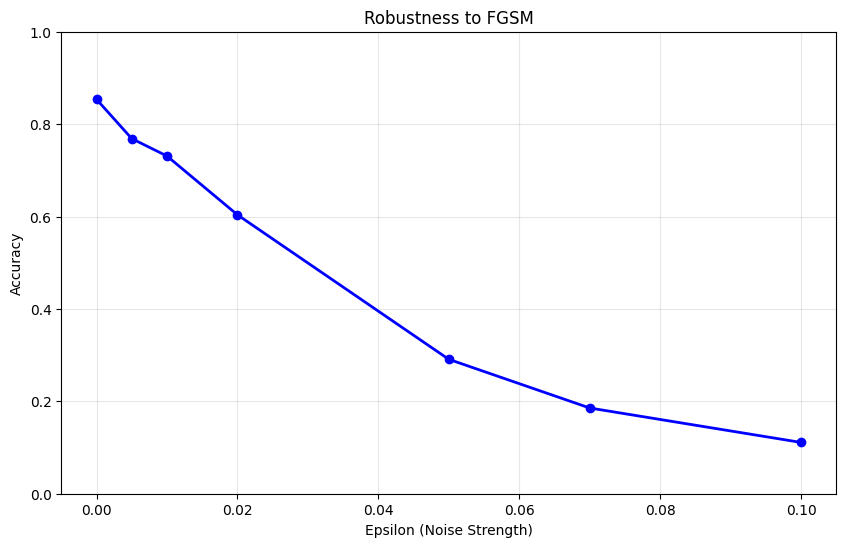

In [ ]:
epsilons = [0, 0.005, 0.01, 0.02, 0.05, 0.07, 0.1] #epsilon values defining the magnitude of the FGSM attack

classifier.eval()
accuracies_fgsm = []

test_loader_attack = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0
)

for eps in epsilons:
    total_correct = 0
    total_samples = 0

    for data in tqdm(test_loader_attack, desc=f"Epsilon {eps}", leave=False):
        pointcloud, target = data
        points = pointcloud.permute(0, 2, 1).to(device)
        target = target[:, 0].to(device).long()

        points.requires_grad = True

        try:
            pred_logits = classifier(points[:, :3, :], points[:, 3:, :])
            loss = F.cross_entropy(pred_logits, target)

            classifier.zero_grad()
            loss.backward()

            data_grad = points.grad.data
            points_adv = fgsm_attack(points, eps, data_grad).detach() #the attack

            with torch.no_grad():
                adv_logits = classifier(points_adv[:, :3, :], points_adv[:, 3:, :])
                pred_choice = adv_logits.argmax(dim=1)
                correct = pred_choice.eq(target).sum().item() #number of correct predictions
                total_correct += correct
                total_samples += points.size(0)

        except RuntimeError as e:
            if "out of memory" in str(e):
                print("ATTENTION: Out of memory")
                torch.cuda.empty_cache()
                continue
            else:
                raise e

        del points, loss, pred_logits, data_grad, points_adv


    if total_samples > 0:
        acc = total_correct / total_samples
        accuracies_fgsm.append(acc)
        print(f"Epsilon : {eps:.3f} | Accuracy : {acc:.4f}")
    else:
        accuracies_fgsm.append(0)

    torch.cuda.empty_cache()

#plot
plt.figure(figsize=(10, 6))
plt.plot(epsilons, accuracies_fgsm, 'o-', linewidth=2, color='blue')
plt.title('Robustness to FGSM')
plt.xlabel('Epsilon (Noise Strength)')
plt.ylabel('Accuracy')
plt.grid(True, alpha=0.3)
plt.ylim(0, 1.0)
plt.show()

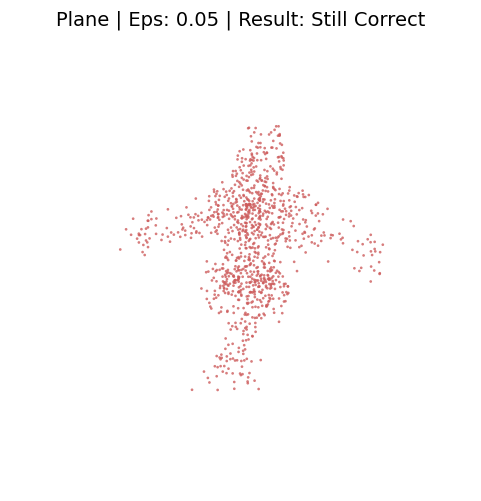

In [ ]:
TARGET_CLASS_INDEX = 0  #plane class
EPSILON = 0.05 #magnitude of the attack

def plot_fgsm(points_np, title_text, color_style='blue', filename=None, elev=150, azim=100):
    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111, projection='3d')

    c = 'steelblue' if color_style == 'blue' else 'indianred'
    lbl = 'Original Points' if color_style == 'blue' else 'Adversarial Points'

    ax.scatter(points_np[:, 0], points_np[:, 1], points_np[:, 2],
               s=15, c=c, marker='.', alpha=0.8, label=lbl, linewidths=0)

    ax.axis('off')
    ax.view_init(elev=elev, azim=azim)

    plt.title(title_text, fontsize=14, color='black', pad=-10)
    plt.show()

#we are looking for a plane which is initially well classified, and still well classified after the attack is performed
classifier.eval()
found = False

for data in test_loader:
    pointcloud, target = data
    target = target[:, 0]

    indices_avion = (target == TARGET_CLASS_INDEX).nonzero(as_tuple=True)[0]
    if len(indices_avion) == 0: continue

    idx = indices_avion[0]
    single_obj = pointcloud[idx].unsqueeze(0).permute(0, 2, 1).to(device)
    single_target = target[idx].unsqueeze(0).to(device).long()

    single_obj.requires_grad = True

    pred_init = classifier(single_obj[:, :3, :], single_obj[:, 3:, :])
    pred_cls_init = pred_init.max(1)[1].item()

    if pred_cls_init != single_target.item():
        continue

    found = True

    loss = F.cross_entropy(pred_init, single_target)
    classifier.zero_grad()
    loss.backward()

    data_grad = single_obj.grad.data
    points_attacked = fgsm_attack(single_obj, EPSILON, data_grad).detach()

    with torch.no_grad():
        pred_attacked = classifier(points_attacked[:, :3, :], points_attacked[:, 3:, :])
        pred_cls_attacked = pred_attacked.max(1)[1].item()

    status = "Still Correct" if pred_cls_attacked == TARGET_CLASS_INDEX else f"Misclassified as {pred_cls_attacked}"
    pts_np_attacked = points_attacked[0].cpu().numpy().T

    plot_fgsm(
        pts_np_attacked,
        title_text=f"Plane | Eps: {EPSILON} | Result: {status}",
        color_style='red'
    )

    break

if not found:
    print("No correctly classified plane found after FGSM adversarial attack")